<a href="https://colab.research.google.com/github/fikriarrayyan/SDGS_PREDIKSI_PERUBAHAN_SUHU/blob/main/SDGS_PREDIKSI_PERUBAHAN_SUHU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

uploaded = files.upload()

Saving FAOSTAT_data_en_11-1-2024.csv to FAOSTAT_data_en_11-1-2024.csv


In [2]:
df = pd.read_csv(
    "FAOSTAT_data_en_11-1-2024.csv",
    encoding="latin1"
)

print("Ukuran dataset:", df.shape)

display(df.head())

Ukuran dataset: (241893, 14)


,ï»¿Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Months Code,Months,Year Code,Year,Unit,Value,Flag,Flag Description
0,ET,Temperature change on land,4,Afghanistan,7271,Temperature change,7001,January,1961,1961,Â°c,0.745,E,Estimated value
1,ET,Temperature change on land,4,Afghanistan,7271,Temperature change,7001,January,1962,1962,Â°c,0.015,E,Estimated value
2,ET,Temperature change on land,4,Afghanistan,7271,Temperature change,7001,January,1963,1963,Â°c,2.706,E,Estimated value
3,ET,Temperature change on land,4,Afghanistan,7271,Temperature change,7001,January,1964,1964,Â°c,-5.250,E,Estimated value
4,ET,Temperature change on land,4,Afghanistan,7271,Temperature change,7001,January,1965,1965,Â°c,1.854,E,Estimated value


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241893 entries, 0 to 241892
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ï»¿Domain Code    241893 non-null  object 
 1   Domain            241893 non-null  object 
 2   Area Code (M49)   241893 non-null  int64  
 3   Area              241893 non-null  object 
 4   Element Code      241893 non-null  int64  
 5   Element           241893 non-null  object 
 6   Months Code       241893 non-null  int64  
 7   Months            241893 non-null  object 
 8   Year Code         241893 non-null  int64  
 9   Year              241893 non-null  int64  
 10  Unit              241893 non-null  object 
 11  Value             231633 non-null  float64
 12  Flag              241893 non-null  object 
 13  Flag Description  241893 non-null  object 
dtypes: float64(1), int64(5), object(8)
memory usage: 25.8+ MB


In [4]:
print(df.columns)
print("\nJumlah data duplikat:", df.duplicated().sum())
print("\nJumlah nilai kosong:")
print(df.isnull().sum())

Index(['ï»¿Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code',
       'Element', 'Months Code', 'Months', 'Year Code', 'Year', 'Unit',
       'Value', 'Flag', 'Flag Description'],
      dtype='object')

Jumlah data duplikat: 0

Jumlah nilai kosong:
ï»¿Domain Code          0
Domain                  0
Area Code (M49)         0
Area                    0
Element Code            0
Element                 0
Months Code             0
Months                  0
Year Code               0
Year                    0
Unit                    0
Value               10260
Flag                    0
Flag Description        0
dtype: int64


In [5]:
# Menghapus baris yang memiliki nilai kosong pada kolom Value
df = df.dropna(subset=['Value'])

print("Ukuran dataset setelah cleaning:", df.shape)
print("Jumlah nilai kosong setelah cleaning:", df['Value'].isnull().sum())

Ukuran dataset setelah cleaning: (231633, 14)
Jumlah nilai kosong setelah cleaning: 0


In [6]:
display(df.head())

,ï»¿Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Months Code,Months,Year Code,Year,Unit,Value,Flag,Flag Description
0,ET,Temperature change on land,4,Afghanistan,7271,Temperature change,7001,January,1961,1961,Â°c,0.745,E,Estimated value
1,ET,Temperature change on land,4,Afghanistan,7271,Temperature change,7001,January,1962,1962,Â°c,0.015,E,Estimated value
2,ET,Temperature change on land,4,Afghanistan,7271,Temperature change,7001,January,1963,1963,Â°c,2.706,E,Estimated value
3,ET,Temperature change on land,4,Afghanistan,7271,Temperature change,7001,January,1964,1964,Â°c,-5.250,E,Estimated value
4,ET,Temperature change on land,4,Afghanistan,7271,Temperature change,7001,January,1965,1965,Â°c,1.854,E,Estimated value


In [7]:
print("Nilai minimum:", df['Value'].min())
print("Nilai maksimum:", df['Value'].max())
print("Nilai rata-rata:", df['Value'].mean())
print("Nilai median:", df['Value'].median())

Nilai minimum: -9.272
Nilai maksimum: 11.753
Nilai rata-rata: 0.5422182892765711
Nilai median: 0.468


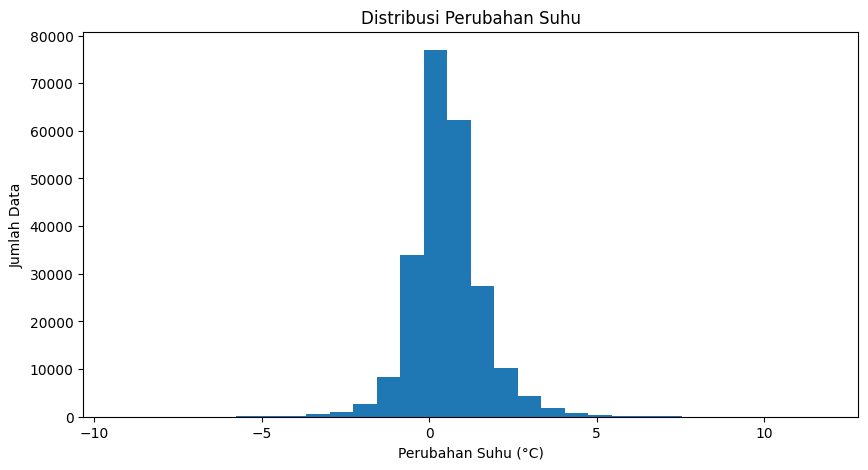

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df['Value'], bins=30)
plt.xlabel('Perubahan Suhu (°C)')
plt.ylabel('Jumlah Data')
plt.title('Distribusi Perubahan Suhu')
plt.show()

In [9]:
# Menentukan batas kategori berdasarkan distribusi data
q1 = df['Value'].quantile(1/3)
q2 = df['Value'].quantile(2/3)

print("Batas kategori 1:", q1)
print("Batas kategori 2:", q2)


Batas kategori 1: 0.134
Batas kategori 2: 0.835


In [10]:
# Membuat kategori perubahan suhu
def buat_kategori(value):
    if value < q1:
        return 'Rendah'
    elif value < q2:
        return 'Sedang'
    else:
        return 'Tinggi'

df['Kategori'] = df['Value'].apply(buat_kategori)

print(df['Kategori'].value_counts())

Kategori
Tinggi    77289
Sedang    77264
Rendah    77080
Name: count, dtype: int64


In [11]:
# Menentukan fitur (X) dan target (y)
X = df[['Area', 'Months', 'Year']]
y = df['Kategori']

print("Fitur (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Fitur (X):
          Area   Months  Year
0  Afghanistan  January  1961
1  Afghanistan  January  1962
2  Afghanistan  January  1963
3  Afghanistan  January  1964
4  Afghanistan  January  1965

Target (y):
0    Sedang
1    Rendah
2    Tinggi
3    Rendah
4    Tinggi
Name: Kategori, dtype: object


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Kolom teks yang perlu diubah menjadi angka
categorical_features = ['Area', 'Months']

# Kolom numerik
numeric_features = ['Year']

# Proses encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

print("Preprocessing berhasil dibuat.")

Preprocessing berhasil dibuat.


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah data training:", len(X_train))
print("Jumlah data testing:", len(X_test))

Jumlah data training: 185306
Jumlah data testing: 46327


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

# Membuat model Decision Tree
dt_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42,
        max_depth=10
    ))
])

# Melatih model
dt_model.fit(X_train, y_train)

print("Decision Tree berhasil dilatih.")

Decision Tree berhasil dilatih.


In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Melakukan prediksi pada data testing
y_pred_dt = dt_model.predict(X_test)

# Menghitung akurasi
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Akurasi Decision Tree:", accuracy_dt)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Akurasi Decision Tree: 0.5644224750145703

Classification Report:
              precision    recall  f1-score   support

      Rendah       0.59      0.66      0.62     15416
      Sedang       0.47      0.34      0.39     15453
      Tinggi       0.60      0.69      0.64     15458

    accuracy                           0.56     46327
   macro avg       0.55      0.56      0.55     46327
weighted avg       0.55      0.56      0.55     46327


Confusion Matrix:
[[10162  3208  2046]
 [ 5133  5262  5058]
 [ 1944  2790 10724]]


In [16]:
from sklearn.ensemble import RandomForestClassifier

# Membuat model Random Forest
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

# Melatih model
rf_model.fit(X_train, y_train)

print("Random Forest berhasil dilatih.")

Random Forest berhasil dilatih.


In [17]:
# Melakukan prediksi pada data testing
y_pred_rf = rf_model.predict(X_test)

# Menghitung akurasi
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Akurasi Random Forest:", accuracy_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Akurasi Random Forest: 0.5805038098732921

Classification Report:
              precision    recall  f1-score   support

      Rendah       0.59      0.63      0.61     15416
      Sedang       0.51      0.44      0.47     15453
      Tinggi       0.62      0.67      0.65     15458

    accuracy                           0.58     46327
   macro avg       0.58      0.58      0.58     46327
weighted avg       0.58      0.58      0.58     46327


Confusion Matrix:
[[ 9715  3484  2217]
 [ 4581  6809  4063]
 [ 2074  3015 10369]]


In [18]:
# Membandingkan hasil kedua algoritma

hasil_perbandingan = pd.DataFrame({
    'Algoritma': ['Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_dt,
        accuracy_rf
    ]
})

display(hasil_perbandingan)

,Algoritma,Accuracy
0,Decision Tree,0.564422
1,Random Forest,0.580504


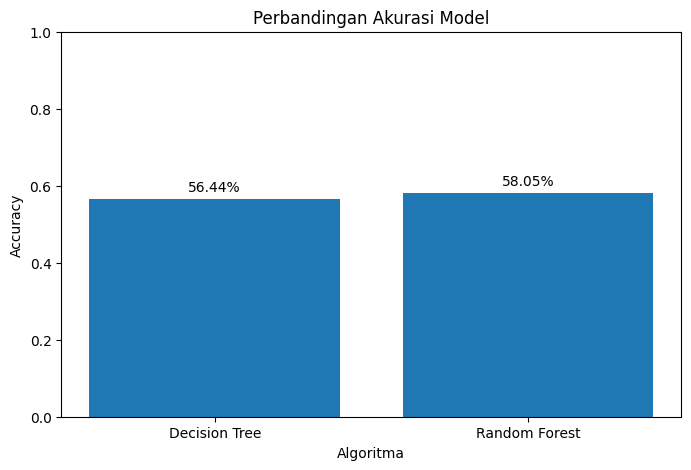

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    hasil_perbandingan['Algoritma'],
    hasil_perbandingan['Accuracy']
)

plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.xlabel('Algoritma')
plt.title('Perbandingan Akurasi Model')

for i, nilai in enumerate(hasil_perbandingan['Accuracy']):
    plt.text(i, nilai + 0.02, f'{nilai:.2%}', ha='center')

plt.show()

In [20]:
id="f3n9x2"
# Membuat tabel perbandingan metrik kedua algoritma

from sklearn.metrics import precision_score, recall_score, f1_score

hasil_metrik = pd.DataFrame({
    'Algoritma': ['Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_dt, average='macro'),
        precision_score(y_test, y_pred_rf, average='macro')
    ],
    'Recall': [
        recall_score(y_test, y_pred_dt, average='macro'),
        recall_score(y_test, y_pred_rf, average='macro')
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_dt, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro')
    ]
})

display(hasil_metrik)

,Algoritma,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.564422,0.552774,0.564484,0.553569
1,Random Forest,0.580504,0.575970,0.580534,0.576889


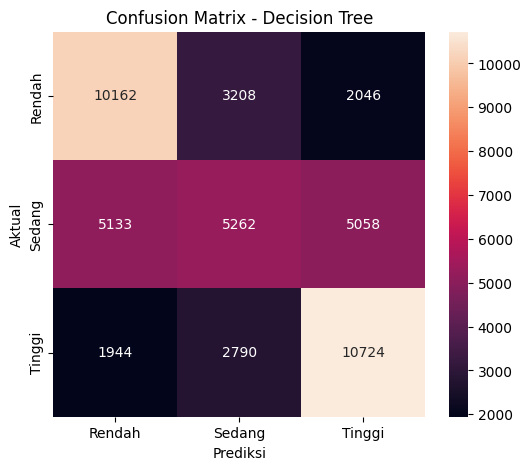

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    xticklabels=['Rendah', 'Sedang', 'Tinggi'],
    yticklabels=['Rendah', 'Sedang', 'Tinggi']
)

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

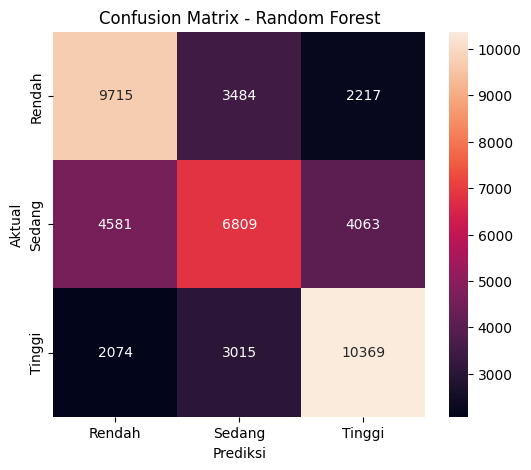

In [22]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    xticklabels=['Rendah', 'Sedang', 'Tinggi'],
    yticklabels=['Rendah', 'Sedang', 'Tinggi']
)

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - Random Forest')
plt.show()